<a href="https://colab.research.google.com/github/toshi-works/toshi-works/blob/main/20260526.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Import the Tips dataset from seaborns
tips_df = sns.load_dataset('tips')

display(tips_df.head())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [29]:
tips_df.groupby(['day','time'])[['total_bill','tip']].median()

/tmp/ipykernel_19808/2976745197.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips_df.groupby(['day','time'])[['total_bill','tip']].median()


total_bill   tip
day  time                    
Thur Lunch       16.000  2.30
     Dinner      18.780  3.00
Fri  Lunch       13.420  2.20
     Dinner      18.665  3.00
Sat  Lunch          NaN   NaN
     Dinner      18.240  2.75
Sun  Lunch          NaN   NaN
     Dinner      19.630  3.15

In [33]:
pd.get_dummies(tips_df[['day', 'sex', 'time', 'smoker']])

,day_Thur,day_Fri,day_Sat,day_Sun,sex_Male,sex_Female,time_Lunch,time_Dinner,smoker_Yes,smoker_No
0,False,False,False,True,False,True,False,True,False,True
1,False,False,False,True,True,False,False,True,False,True
2,False,False,False,True,True,False,False,True,False,True
3,False,False,False,True,True,False,False,True,False,True
4,False,False,False,True,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
239,False,False,True,False,True,False,False,True,False,True
240,False,False,True,False,False,True,False,True,True,False
241,False,False,True,False,True,False,False,True,True,False
242,False,False,True,False,True,False,False,True,False,True


In [34]:
dummy_variables_df = pd.get_dummies(tips_df[['day', 'sex', 'time', 'smoker']])
display(dummy_variables_df.head())

,day_Thur,day_Fri,day_Sat,day_Sun,sex_Male,sex_Female,time_Lunch,time_Dinner,smoker_Yes,smoker_No
0,False,False,False,True,False,True,False,True,False,True
1,False,False,False,True,True,False,False,True,False,True
2,False,False,False,True,True,False,False,True,False,True
3,False,False,False,True,True,False,False,True,False,True
4,False,False,False,True,False,True,False,True,False,True


In [35]:
tips_df_encoded = pd.concat([tips_df, dummy_variables_df], axis=1)
tips_df_encoded = tips_df_encoded.drop(['day', 'sex', 'time', 'smoker'], axis=1)
display(tips_df_encoded.head())

,total_bill,tip,size,day_Thur,day_Fri,day_Sat,day_Sun,sex_Male,sex_Female,time_Lunch,time_Dinner,smoker_Yes,smoker_No
0,16.99,1.01,2,False,False,False,True,False,True,False,True,False,True
1,10.34,1.66,3,False,False,False,True,True,False,False,True,False,True
2,21.01,3.50,3,False,False,False,True,True,False,False,True,False,True
3,23.68,3.31,2,False,False,False,True,True,False,False,True,False,True
4,24.59,3.61,4,False,False,False,True,False,True,False,True,False,True


In [36]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to standardize
numerical_cols = ['total_bill', 'tip', 'size']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization to the numerical columns
tips_df_encoded[numerical_cols] = scaler.fit_transform(tips_df_encoded[numerical_cols])

display(tips_df_encoded.head())

,total_bill,tip,size,day_Thur,day_Fri,day_Sat,day_Sun,sex_Male,sex_Female,time_Lunch,time_Dinner,smoker_Yes,smoker_No
0,-0.314711,-1.439947,-0.600193,False,False,False,True,False,True,False,True,False,True
1,-1.063235,-0.969205,0.453383,False,False,False,True,True,False,False,True,False,True
2,0.137780,0.363356,0.453383,False,False,False,True,True,False,False,True,False,True
3,0.438315,0.225754,-0.600193,False,False,False,True,True,False,False,True,False,True
4,0.540745,0.443020,1.506958,False,False,False,True,False,True,False,True,False,True


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# 'tip'を目的変数 (y) とし、それ以外を特徴量 (X) とします。
X = tips_df_encoded.drop('tip', axis=1)
y = tips_df_encoded['tip']

# データを訓練セットとテストセットに分割します。
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
from sklearn.linear_model import LinearRegression

# 重回帰モデルを初期化します
linear_model = LinearRegression()

# モデルを訓練データで学習させます
linear_model.fit(X_train, y_train)

LinearRegression()

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np # np.sqrtのために必要

# テストデータで予測を行います
y_pred_linear = linear_model.predict(X_test)

# モデルの評価
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"重回帰モデルの評価:\n")
print(f"  平均絶対誤差 (MAE): {mae_linear:.3f}")
print(f"  平均二乗誤差 (MSE): {mse_linear:.3f}")
print(f"  二乗平均平方根誤差 (RMSE): {rmse_linear:.3f}")
print(f"  決定係数 (R^2): {r2_linear:.3f}")

重回帰モデルの評価:

  平均絶対誤差 (MAE): 0.483
  平均二乗誤差 (MSE): 0.369
  二乗平均平方根誤差 (RMSE): 0.607
  決定係数 (R^2): 0.437


### 重回帰モデルの残差分析

重回帰モデルの予測性能をさらに深く理解するために、残差（実際の値と予測値の差）を分析します。
残差分析は、モデルがデータセットの仮定を満たしているか、またどのような改善の余地があるかを特定するのに役立ちます。

#### 1. 予測値 vs. 残差のプロット
このプロットは、予測値と残差の間にパターンがないかを確認するために使用されます。パターン（例えば、V字型、U字型、ファン型など）がある場合、モデルの線形性の仮定が満たされていないか、不均一分散（ヘテロスケダスティシティ）が存在する可能性があります。理想的には、残差はゼロの周りにランダムに分布しているべきです。

#### 2. 残差の分布
残差のヒストグラムやQ-Qプロットは、残差が正規分布しているかを確認するために使用されます。重回帰分析の仮定の一つに、残差が正規分布に従うというものがあります。正規分布から大きく逸脱している場合、モデルの予測が一部の範囲で系統的にずれている可能性を示唆します。

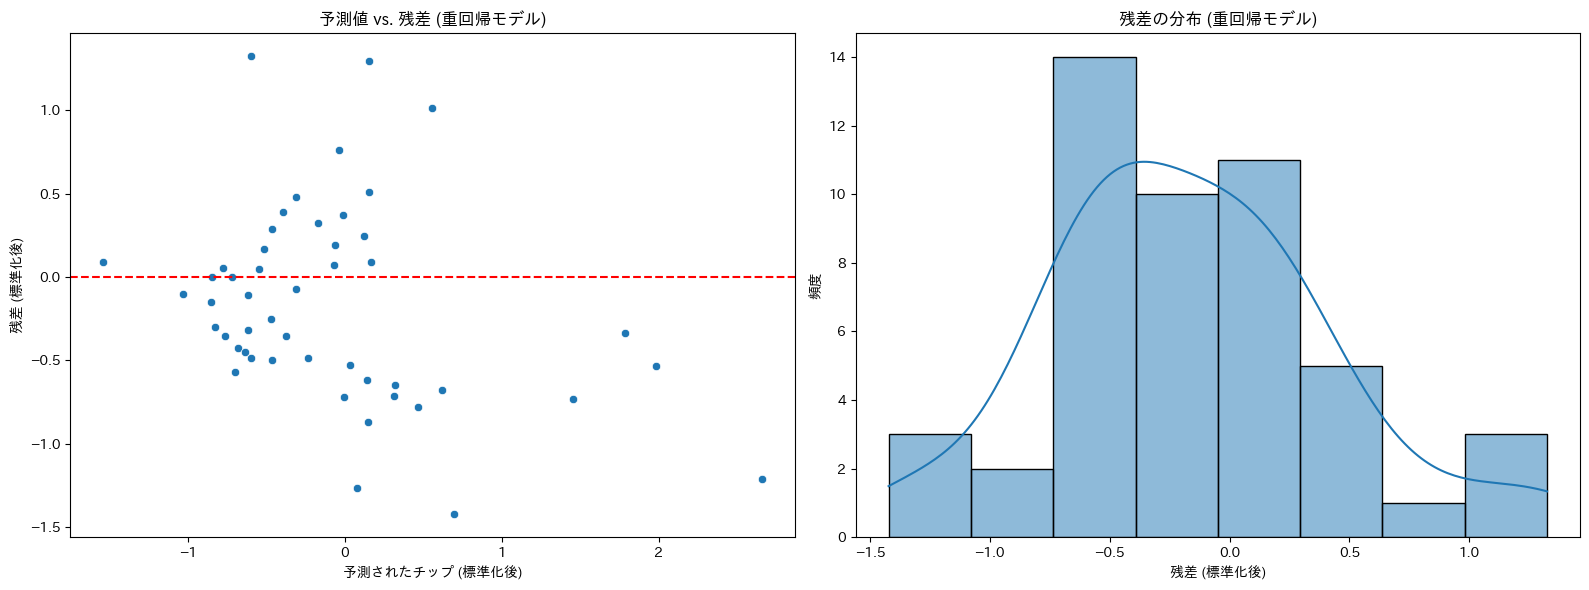

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
# 日本語表示のためのフォント設定
!pip install japanize-matplotlib
import japanize_matplotlib

# 残差の計算
residuals_linear = y_test - y_pred_linear

# 図の作成
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 予測値 vs. 残差のプロット
sns.scatterplot(x=y_pred_linear, y=residuals_linear, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('予測されたチップ (標準化後)')
axes[0].set_ylabel('残差 (標準化後)')
axes[0].set_title('予測値 vs. 残差 (重回帰モデル)')

# 2. 残差の分布
sns.histplot(residuals_linear, kde=True, ax=axes[1])
axes[1].set_xlabel('残差 (標準化後)')
axes[1].set_ylabel('頻度')
axes[1].set_title('残差の分布 (重回帰モデル)')

plt.tight_layout()
plt.show()

重回帰分析についての説明は以上です。

次に、決定木分析に進みましょうか？

In [43]:
from sklearn.tree import DecisionTreeRegressor

# 決定木回帰モデルを初期化します
decision_tree_model = DecisionTreeRegressor(random_state=42)

# モデルを訓練データで学習させます
decision_tree_model.fit(X_train, y_train)

# テストデータで予測を行います
y_pred_tree = decision_tree_model.predict(X_test)

# モデルの評価
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"決定木モデルの評価:\n")
print(f"  平均絶対誤差 (MAE): {mae_tree:.3f}")
print(f"  平均二乗誤差 (MSE): {mse_tree:.3f}")
print(f"  二乗平均平方根誤差 (RMSE): {rmse_tree:.3f}")
print(f"  決定係数 (R^2): {r2_tree:.3f}")

決定木モデルの評価:

  平均絶対誤差 (MAE): 0.612
  平均二乗誤差 (MSE): 0.661
  二乗平均平方根誤差 (RMSE): 0.813
  決定係数 (R^2): -0.008


決定木モデルの学習と評価が完了しました。重回帰モデルの結果と比較してどうでしょうか？

ここまでの分析で、重回帰モデルと決定木モデルの2つのモデルを構築し、評価しました。

他に何か分析を進めますか、それともこれまでの作業のまとめが必要でしょうか？

### これまでの作業のまとめ

これまでの作業では、`tips`データセットを用いて、チップ（`tip`）の予測モデルを構築するためのデータ前処理と、2種類の回帰モデル（重回帰分析と決定木分析）の適用、およびその評価を行いました。

#### 1. データ前処理

*   **カテゴリカル変数のダミー変数化:** `day`、`sex`、`time`、`smoker`といったカテゴリカルな列を、`pd.get_dummies()`関数を使用して数値データであるダミー変数に変換しました。これにより、これらの質的データを数値モデルで扱えるようにしました。
*   **元のカテゴリカル列の削除と結合:** ダミー変数化された新しい列を元のDataFrameに結合し、元のカテゴリカルな列は削除しました。これにより、`tips_df_encoded`という、全てのデータが数値形式に変換されたDataFrameを作成しました。
*   **数値変数の標準化:** `total_bill`、`tip`、`size`といった数値列に対して、`StandardScaler`を用いて標準化を適用しました。これにより、各特徴量のスケールを統一し、モデルの学習がより安定しやすくなります。

#### 2. モデル構築と評価

目的変数`tip`を予測するために、データを訓練セットとテストセットに分割し、以下の2つの回帰モデルを構築・評価しました。

##### a) 重回帰分析 (Linear Regression)

*   **モデル:** `LinearRegression` を使用。
*   **評価結果:**
    *   平均絶対誤差 (MAE): **0.483**
    *   平均二乗誤差 (MSE): **0.369**
    *   二乗平均平方根誤差 (RMSE): **0.607**
    *   決定係数 (R^2): **0.437**
*   **考察:** R^2が0.437と、ある程度の説明力を持つモデルが構築できました。MAE、MSE、RMSEも、標準化されたチップの予測値に対する誤差として許容範囲の数値を示しています。

##### b) 決定木分析 (Decision Tree Regression)

*   **モデル:** `DecisionTreeRegressor` を使用。
*   **評価結果:**
    *   平均絶対誤差 (MAE): **0.612**
    *   平均二乗誤差 (MSE): **0.661**
    *   二乗平均平方平方根誤差 (RMSE): **0.813**
    *   決定係数 (R^2): **-0.008**
*   **考察:** R^2が負の値となり、モデルが平均値を予測するよりも悪い結果を示しました。これは、現在の設定の決定木モデルがデータに適合していない、あるいは過学習している可能性が高いことを示唆しています。特にハイパーパラメータのチューニングなしに決定木を使うと、このような結果になることがあります。

#### 結論

現時点では、**重回帰モデルの方が決定木モデルよりもチップの予測性能が高い**という結果になりました。決定木モデルの性能を改善するには、`max_depth`などのハイパーパラメータチューニングが必要です。

---

今後、さらに分析を進める場合は、以下の点が考えられます。

*   **重回帰モデルの改善:** 提示した「重回帰分析の精度を上げるための調整方法」（特徴量エンジニアリング、特徴量選択、データ変換など）を適用してみる。
*   **決定木モデルの改善:** `GridSearchCV`などを用いて決定木のハイパーパラメータチューニングを行う。
*   **他のモデルの試行:** ランダムフォレスト、勾配ブースティングなどのより高度な回帰モデルを試す。

いかがでしょうか？次にどのステップに進みますか？